## 1D Fiting with SASView from notebook
## prism model template notebook
## with 1D assembly side by side of N particles

* import all the packages
* install packages before using a separate notebook
* better to work in a dedicated python environnement

In [1]:
import numpy as np

import sasmodels
import sasmodels.core
import sasmodels.data
import sasmodels.bumps_model

import sasdata

from sasdata.dataloader.loader import Loader
from sasmodels.data import load_data
from sasmodels.data import plot_theory

import bumps
import bumps.fitters
import bumps.names
import bumps.fitproblem

import os


* configuration of matplotlib for plots 

In [2]:
"""
import matplotlib.pyplot and set custom default settings for plots
"""
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import matplotlib.pyplot as plt

plt.rc('font', size=14) 
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)
plt.rc('figure', titlesize=18)
plt.rc("figure", figsize=(5,5))
plt.rc("lines", linewidth=3)

* example of checking the version of a SASView packages

In [3]:
sasdata.__version__

'0.11.0'

In [4]:
sasmodels.__version__

'1.1.0a2.dev4+ge63cb8e84'

### Load a 1D data file

* load an experimental data file .dat 
* define here filename and path on your computer

In [3]:
filename='./data-examples/PR8_50mM8A2_01302{00000}_AzInt_Px_399_sub.dat'


Process the data file:
* use `skiheader` to skip the header 
* use `skipmin` to skip data points at low q values
* use `skipmax` to skip data points at large q values
* load the data in a numpy array and show a first plot
* use `slicing_step` to reduce the number of data points (slicing_step=3 means that 1 point over 3 is taken)
* use `rescale` the intensity coefficient for rescaling (in cm-1) if not done previously
* use `coeff` to compute realistic error bars as a percentage of intensity values (coeff=0.1 means 10% of intensity error bars)
* transform the numpy array into a suitable 1D data set using `sasmodels.data.Data1D`
* data plot shows the complete data `data_np` set and the new one `data`

total number of data points:  1206
after skip at low and large q values: 606
after slicing: 303


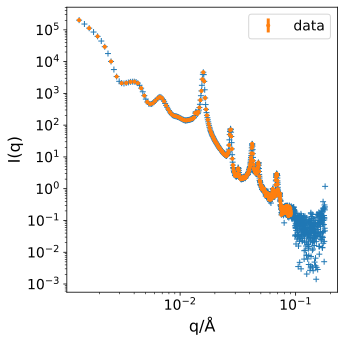

In [4]:
#number of lines in the header
skipheader=4

data_np = np.loadtxt(filename, skiprows=skipheader)

total_data_number=data_np.shape[0] #total number of data points in the file
print('total number of data points: ',total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')

#number of points to skip at low q values
skipmin=0
data_np = np.loadtxt(filename, skiprows=skipheader+skipmin)

# number of data point to skip at the end
skipmax=600
number_of_data=total_data_number-skipmax-skipmin

print('after skip at low and large q values:', number_of_data)

slicing_step=2 # step of slicing 

# rescaling of intensity values
# TP UE soft matter 2026
# scaling factor from SWING to Cu-SAXS to be in cm-1
rescale=1

# new error bars: 10 % of intensity values
coeff=0.1

data = sasmodels.data.Data1D(x=data_np[0:number_of_data:slicing_step,0], 
                             y=rescale*data_np[0:number_of_data:slicing_step,1], 
                             dy=rescale*coeff*abs(data_np[0:number_of_data:slicing_step,1]))

number_of_data_new=data.x.shape[0]
print('after slicing:', number_of_data_new)

sasmodels.data.plot_data(data)

* plot of the new data set `data`

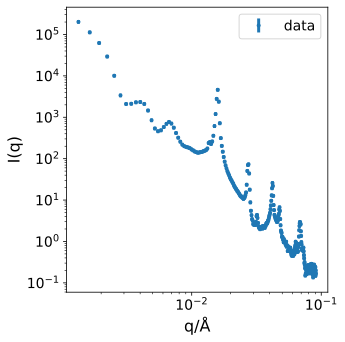

In [5]:
sasmodels.data.plot_data(data)

### save `data` in a new data file
* add `_new`at the end of the name

In [8]:
newfilename=filename[:-4]+"_new.dat" # data 

with open(newfilename, "w") as f:
    f.write("raw data file is:"+filename+"\n")
    f.write("number of data points: \t"+str(number_of_data_new)+"\n")

with open(newfilename, "a") as fa:
    for i in range(0,number_of_data_new):
        line_to_write=str(data.x[i])+"\t"+str(data.y[i])+"\t"+str(data.dy[i])+"\n"
        fa.write(line_to_write)

### fit the data

* create the computation `kernel` selecting the `cylinder` model
* create the `model` interfaced with bump module
* create the `experiment`, containing both data and model

In [6]:

kernel = sasmodels.core.load_model("assembly_1D_prism")
params = {} # default parameters for now
model = sasmodels.bumps_model.Model(kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

* default values of all parameters

In [7]:
kernel.info.parameters.defaults

{'scale': 1,
 'background': 0.001,
 'sld': 126.0,
 'sld_solvent': 9.4,
 'n_sides': 5,
 'radius_average': 500,
 'length': 5000,
 'a_lattice': 100,
 'n_size': 10}

#### preliminary step: manual adjustment of parameters before fiting

Don't forget updating the SLD values (x10-6 A-2) !
* gold: 125
* silver: 77.9
* water: 9.47
* toluene: 8.4

In [8]:
sld_gold=125
sld_silver=77.9
sld_water=9.47
sld_toluene=8.4

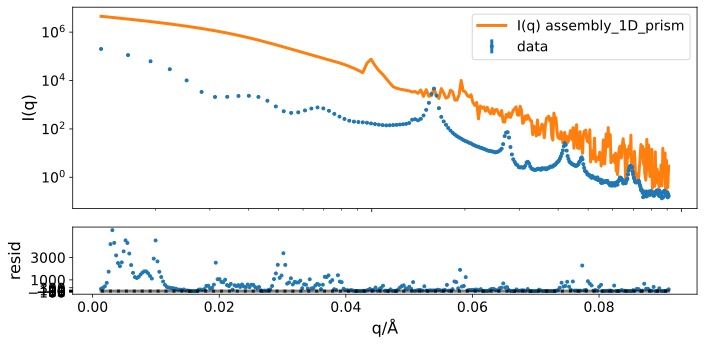

In [ ]:
kernel = sasmodels.core.load_model("assembly_1D_prism")


params = {
    "n_sides": 5,
    "radius_average": 300,
    "radius_average_pd_type": 'gaussian', 
    "radius_average_pd": 0.01, 
    "radius_average_pd_n": 8, 
    "radius_average_pd_nsigma": 3,
    "length": 1170,
    "length_pd_type": 'gaussian', 
    "length_pd": 0.05, 
    "length_pd_n": 8, 
    "length_pd_nsigma": 3,
    
     
    "sld": sld_gold,         
    "sld_solvent": sld_water,
    "background": 0.000000,
    "scale": 0.000003,

    "a_lattice": 650,
    "n_size": 40,

}

model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

plt.figure(figsize=(10,5))

experiment.plot()

### Explanation of the polydispersity parameters

The polydispersity is set using a special set of \*\_pd\_\* parameters:
* `*_pd*` is the width of the polydispersity and the exact definition will depend on the type of distribution specified; in this cause of a 'gaussian` distribution, it is defined as as $\frac{\sigma}{x_{mean}}$
* `*_pd_type*` defines the type of polydispersity distribution used
* `*_pd_n` corresponds to the the number of points in the distribution used by the calculation (Npts in the image below)
* `*_pd_nsigma` sets the range of the distribution sampled (Nsigmas in the image below)

For example, radius polydispersity could be defined by specifying **all four** of the pd parameters. With the default values, this would look like:
* `radius_pd = 0`
* `radius_pd_type = 'gaussian'`
* `radius_pd_n = 35`
* `radius_pd_nsigma = 3`

The available polydispersity distributions are defined in the SasView [documentation](https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/pd/polydispersity.html) but we can access them directly through the sasmodels `weights` module.

The 'gaussian' distribution is claculed by:

$$
f(x) = \frac{1}{Norm}\exp\left(-\frac{(x-x_{mean})^2}{2\sigma^2}\right)
$$

<img src=https://www.sasview.org/docs/_images/pd_gaussian.jpg>

*Image source: https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/pd/polydispersity.html*


## fiting the data

* choice of the initial values for parameters
* choice of the fiting parameters with their fiting range

In [13]:
model = sasmodels.bumps_model.Model(model=kernel, **params)


model.scale.range(0.00000001,0.00000005)      
model.background.range(1e-06, 1e-05)   
model.radius_average.range(280, 320)          
model.radius_average_pd.range(0.0, 0.03)
#model.length.range(1000, 1200)          
#model.length_pd.range(0.0, 0.2)

 

experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

problem = bumps.fitproblem.FitProblem(experiment)

results = bumps.fitters.fit(problem, 
                            method='lm', 
                            steps=20,   
                            ftol=1.5e-06, 
                            xtol=1.5e-06, 
                            verbose=True)

plt.figure(figsize=(8,8))
print(problem.summarize())
print(model.state())
print(f"Chi-Squared: {problem.chisq()}")
sasmodels.data.plot_theory(data,experiment.Iq_calc)

c:\Users\IMPÉROR\CloudStation\dev-SASView\.venv\Lib\site-packages\bumps\fitproblem.py:631: UserWarning: Unsatisfied constraints: [background=0.0 is outside (1e-06,1e-05),
scale=3e-06 is outside (1e-08,5e-08)]
  warnings.warn("Unsatisfied constraints: [%s]" % (",\n".join(broken)))


step 1 cost 101.153(16)
                              background |.........      1e-06 in [1e-06, 1e-05]
                          radius_average ....|.....        300 in [280, 320]
                       radius_average_pd ...|......       0.01 in [0, 0.03]
                                   scale .........|      5e-08 in [1e-08, 5e-08]
step 2 cost 101.151(16)
                              background .........|      1e-05 in [1e-06, 1e-05]
                          radius_average ....|.....    299.533 in [280, 320]
                       radius_average_pd ...|......  0.0114277 in [0, 0.03]
                                   scale .........|      5e-08 in [1e-08, 5e-08]


KeyboardInterrupt: 

The current value of all parameters can always be called using `model.state()`:

In [ ]:
print(model.state())
print(problem.summarize())
print(problem.chisq())




{'scale': 2.3341425525983055e-08, 'background': 2.930302925433074e-06, 'sld': 125.0, 'sld_solvent': 9.47, 'n_sides': 5.0, 'n_sides_pd': 0.0, 'n_sides_pd_n': 35.0, 'n_sides_pd_nsigma': 3.0, 'radius_average': 296.944687576168, 'radius_average_pd': 0.03, 'radius_average_pd_n': 8.0, 'radius_average_pd_nsigma': 3.0, 'length': 1170.0, 'length_pd': 0.05, 'length_pd_n': 8.0, 'length_pd_nsigma': 3.0, 'up_frac_i': 0.0, 'up_frac_f': 0.0, 'up_theta': 90.0, 'up_phi': 0.0, 'sld_M0': 0.0, 'sld_mtheta': 0.0, 'sld_mphi': 0.0, 'sld_solvent_M0': 0.0, 'sld_solvent_mtheta': 0.0, 'sld_solvent_mphi': 0.0, 'n_sides_pd_type': 'gaussian', 'radius_average_pd_type': 'gaussian', 'length_pd_type': 'gaussian'}
                              background ..|....... 2.9303e-06 in [1e-06, 1e-05]
                          radius_average ....|.....    296.945 in [280, 320]
                       radius_average_pd .........|       0.03 in [0, 0.03]
                                   scale ...|...... 2.33414e-08 in [1e-08, 5e

* store the fited values in R_fit and L_fit

In [ ]:
# value of R after fiting
R_fit=model.radius_average.value

# value of Thickness after fiting (Replaces L_fit)
T_fit=model.length.value

#### Save the fited curve in a file
* `_fit` is added at the end of filename

In [ ]:
fitfilename=filename[:-4]+"_fit.dat" # fit 

with open(fitfilename, "w") as f:
    f.write("raw data file is:"+filename+"\n")
    f.write("number of data points: \t"+str(number_of_data_new)+"\n")

with open(fitfilename, "a") as fa:
    for i in range(0,number_of_data_new-1):
        line_to_write=str(data.x[i])+"\t"+str(experiment.Iq_calc[i])+"\n"
        fa.write(line_to_write)

In [ ]:
results.x

array([2.93030293e-06, 2.96944688e+02, 3.00000000e-02, 2.33414255e-08])

In [ ]:
results.dx

array([1.13275327e-07, 7.20614504e-01, 2.82277999e-03, 2.00819032e-10])

### final plot
* use this one for a nice .svg output

0.9817971441624265


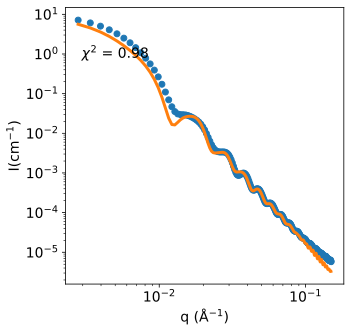

In [ ]:
data_final = np.loadtxt(newfilename, skiprows=3)

fit_final = np.loadtxt(fitfilename, skiprows=3)

plt.loglog(data_final[:,0], data_final[:,1], 'o')
plt.loglog(fit_final[:,0], fit_final[:,1])
plt.xlabel('q '+r'(Å$^{-1}$)',fontsize=14)
plt.ylabel('I'+r'(cm$^{-1}$)',fontsize=14)
plt.text(0.005,0.8,r'$\chi^2$ = '+f"{problem.chisq():.2f}",fontsize=14,horizontalalignment='center')
print(problem.chisq())
